# LoRA Fisher Eigenvalue Distribution Experiment

Fast exploration notebook for repeated MNIST distribution-shift runs.

In [43]:
from pathlib import Path
import sys

ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
sys.path.insert(0, str(ROOT))

import matplotlib.pyplot as plt
import numpy as np

from src import Experiment, ExperimentConfig


In [44]:
# Tune these first; defaults in src.experiment are closer to the proposed full run.
n_experiments = 3
base_config = dict(
    n_initial=10_000,
    initial_epochs=8,
    dt=0.001,
    t_stop=0.5,
    m=20,
    ewc_rho=0.1,
    ewc_lambda=10.0,
    lora_rank=2,
    fisher_samples=512,
)


In [45]:
results = []
for seed in range(n_experiments):
    config = ExperimentConfig(seed=seed, **base_config)
    result = Experiment(config).run_experiment()
    results.append(result)
    print(
        f"seed={seed} final acc9={result.accuracy_9[-1]:.3f} "
        f"lora rank_eff={result.lora_stats['effective_rank']:.1f} "
        f"full rank_eff={result.full_stats['effective_rank']:.1f}"
    )


seed=0 final acc9=0.935 lora rank_eff=6.4 full rank_eff=12.2
seed=1 final acc9=0.950 lora rank_eff=5.0 full rank_eff=9.3
seed=2 final acc9=0.925 lora rank_eff=5.6 full rank_eff=11.9


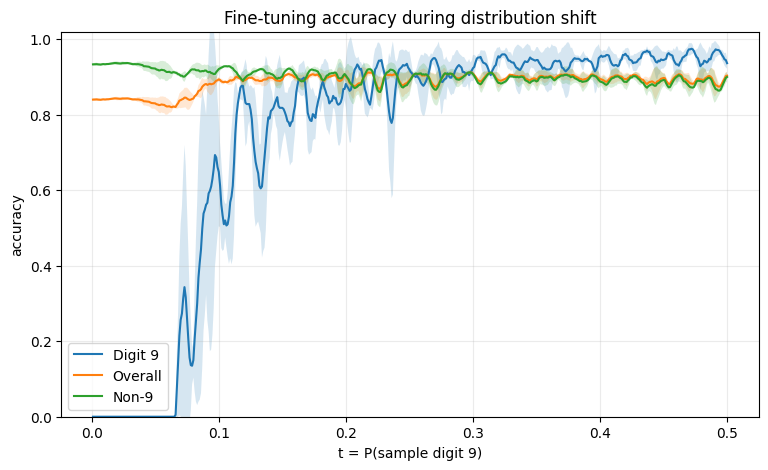

In [46]:
def stack_series(name):
    min_len = min(len(getattr(r, name)) for r in results)
    return np.stack([getattr(r, name)[:min_len] for r in results])

t = stack_series('t_values')[0]
series = {
    'Digit 9': stack_series('accuracy_9'),
    'Overall': stack_series('accuracy_all'),
    'Non-9': stack_series('accuracy_non9'),
}

fig, ax = plt.subplots(figsize=(9, 5))
for label, values in series.items():
    mean = values.mean(axis=0)
    sem = values.std(axis=0, ddof=1) / np.sqrt(values.shape[0]) if values.shape[0] > 1 else np.zeros_like(mean)
    ax.plot(t, mean, label=label)
    ax.fill_between(t, mean - 1.96 * sem, mean + 1.96 * sem, alpha=0.18)
ax.set_xlabel('t = P(sample digit 9)')
ax.set_ylabel('accuracy')
ax.set_title('Fine-tuning accuracy during distribution shift')
ax.set_ylim(0, 1.02)
ax.legend()
ax.grid(alpha=0.25)
plt.show()


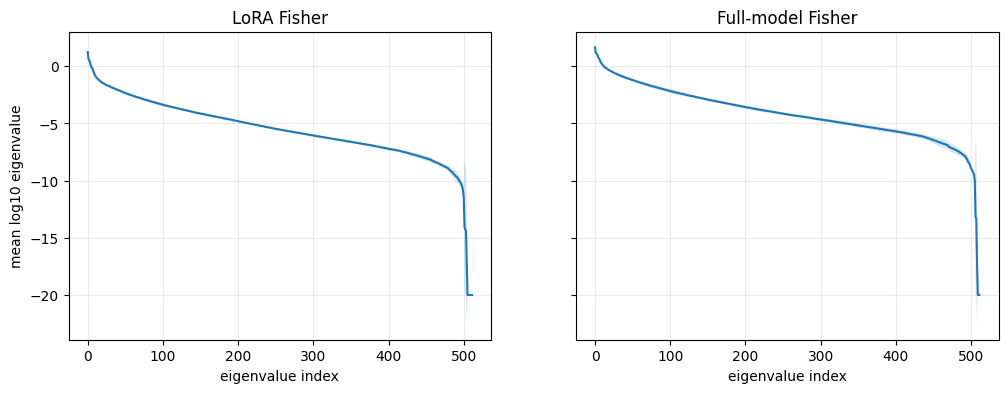

In [47]:
def padded_log_eigs(attr):
    arrays = [np.asarray(getattr(r, attr), dtype=float) for r in results]
    min_len = min(len(a) for a in arrays)
    clipped = np.stack([a[:min_len] for a in arrays])
    return np.log10(np.clip(clipped, 1e-20, None))

lora_log = padded_log_eigs('lora_eigenvalues')
full_log = padded_log_eigs('full_eigenvalues')

fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)
for ax, values, title in [(axes[0], lora_log, 'LoRA Fisher'), (axes[1], full_log, 'Full-model Fisher')]:
    x = np.arange(values.shape[1])
    mean = values.mean(axis=0)
    sem = values.std(axis=0, ddof=1) / np.sqrt(values.shape[0]) if values.shape[0] > 1 else np.zeros_like(mean)
    ax.plot(x, mean)
    ax.fill_between(x, mean - 1.96 * sem, mean + 1.96 * sem, alpha=0.18)
    ax.set_title(title)
    ax.set_xlabel('eigenvalue index')
    ax.grid(alpha=0.25)
axes[0].set_ylabel('mean log10 eigenvalue')
plt.show()


In [48]:
summary = {
    'lora_effective_rank': [r.lora_stats['effective_rank'] for r in results],
    'full_effective_rank': [r.full_stats['effective_rank'] for r in results],
    'lora_condition_number': [r.lora_stats['condition_number'] for r in results],
    'full_condition_number': [r.full_stats['condition_number'] for r in results],
}
summary


{'lora_effective_rank': [6.425450325012207,
  5.014994144439697,
  5.633970737457275],
 'full_effective_rank': [12.220319747924805,
  9.317963600158691,
  11.922017097473145],
 'lora_condition_number': [3296123944960.0,
  14236792127488.0,
  12971811012608.0],
 'full_condition_number': [1232342351872.0, 1136611557376.0, 19978489167872.0]}